In this notebook, we will use the YOLOv8 models to detect the labeled cards and fish in the sardine images. Then we will use the detected card's bounding box to extract the pixel per centimeter (PPCM) value from the card and use it to calculate the size of the fish in centimeters. Finally, we will save the results in a CSV file for further analysis.

In [1]:
! pip install ultralytics==8.0.188 pillow==10.2.0 opencv-python==4.8.0.76 tensorflow==2.12.0 numpy==1.23.1

  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl.metadata (1.8 kB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-manylinu

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Import Libraries

In [2]:
from ultralytics import YOLO

In [3]:
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import numpy as np
import cv2, os, math

Load segmentation models

In [ ]:
scale_model = YOLO(r"/content/drive/MyDrive/Sowmya /models/card detection/runs/segment/train3(60 epochs)/weights/best.pt")  # load a custom model trained for card detection instead of scale detection
fish_model = YOLO(r"/content/drive/MyDrive/Sowmya /models/segmentation/kartik/fish.pt")  # load a custom model

Prepare dataset

In [5]:
def circumference_area(img):
    # Load the segmented fish image
    # image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    image = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Threshold the image to create a binary mask
    _, binary_mask = cv2.threshold(image, 1, 255, cv2.THRESH_BINARY)

    # Find contours in the binary mask
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Ensure at least one contour was found
    if len(contours) > 0:
        # Get the largest contour (presumably the fish)
        largest_contour = max(contours, key=cv2.contourArea)

        # Calculate the circumference of the contour
        circumference = cv2.arcLength(largest_contour, closed=True)

        # Calculate the area enclosed by the contour
        area = cv2.contourArea(largest_contour)

        return circumference, area

In [6]:
def get_segmented_img(pred, index=0):
    img_shape = pred.orig_shape
    img = pred.orig_img.copy()
    height, width = img_shape[0], img_shape[1]
    masks = pred.masks.xy
    seg_img_list = []
    for i in range(len(masks)):
        if i != index: continue
        mask = masks[i]
        mask_points = mask.astype(int)
        binary_mask = np.zeros((height, width), dtype=np.uint8)
        cv2.fillPoly(binary_mask, [mask_points], 255)
        masked_img = cv2.bitwise_and(img, img, mask=binary_mask)
        x, y, w, h = cv2.boundingRect(mask_points)
        segment_image = np.zeros((height, width, 3), dtype=np.uint8)
        segment_image[y:y+h, x:x+w] = masked_img[y:y+h, x:x+w]
        segment_image = segment_image[y:y+h, x:x+w]
        white_background = False
        if white_background:
            black_mask = np.all(segment_image == [0, 0, 0], axis=-1)
            segment_image[black_mask] = [255, 255, 255]
        seg_img_list.append(segment_image)
    return seg_img_list

In [7]:
def get_object_height(img_path, model, conf=0.75, iou=0.5, seg=False):
    seg_img_list = None
    results = model(img_path, conf=conf, iou=iou, verbose=False)
    if len(results[0].boxes.cls) != 0:
        index = 0
        hp = int(results[0].boxes.xywh[index][3])
        wp = int(results[0].boxes.xywh[index][2])
        dp = int(math.hypot(hp, wp))
        if hp<wp: (hp, wp) = (wp, hp)
        obj_present = True
        if seg: seg_img_list = get_segmented_img(results[0], index)
    else:
        hp, wp, dp = (0, 0, 0)
        obj_present = False
    return hp, wp, dp, obj_present, seg_img_list


def fish_measures(img_path):
    # Predict with the scale model
    scale_hp, scale_wp, scale_dp, scale, _ = get_object_height(img_path, scale_model)
    # Predict with the fish model
    fish_hp, fish_wp, fish_dp, fish, fish_img_list = get_object_height(img_path, fish_model,
                                                     conf=0.75, iou=0.7, seg=True)

    try:
        scale_hcm = 9.5
        one_pixel_value = scale_hcm / scale_hp
        fish_hcm = int(fish_hp * one_pixel_value)
        fish_wcm = int(fish_wp * one_pixel_value)
        fish_dcm = int(fish_dp * one_pixel_value)
        scale_dcm = int(scale_dp * one_pixel_value)
        scale_wcm = int(scale_wp * one_pixel_value)
    except:
        (fish_hcm, fish_wcm, fish_dcm,
         scale_dcm, scale_wcm, one_pixel_value) = (0, 0, 0, 0, 0, 0)

    return (fish_hcm, fish_wcm, fish_dcm, scale_dcm, scale_wcm,
            fish, scale, fish_img_list, one_pixel_value)

In [8]:
def single_img_data(img_path):
    filename = os.path.basename(img_path)
    (fish_hcm, fish_wcm, fish_dcm, scale_dcm, scale_wcm, fish, scale,
     fish_img_list, one_pixel_value) = fish_measures(img_path)
    data = []
    if fish_img_list != None:
        for fish_img in fish_img_list:
            circumference, area = circumference_area(fish_img)
            if one_pixel_value != 0:
                circumference = int(circumference * one_pixel_value)
                area = int(area * one_pixel_value * one_pixel_value)
            data.append((filename, fish_hcm, fish_wcm, fish_dcm,
                         scale_dcm, scale_wcm, one_pixel_value,
                         scale, fish, circumference, area))
    else:
        data.append((filename, fish_hcm, fish_wcm, fish_dcm,
                     scale_dcm, scale_wcm, one_pixel_value,
                     scale, fish, 0, 0))
    return data

In [9]:
!pwd

/content


In [10]:
folderpath = '/content/drive/MyDrive/Sowmya /models/card detection'
%cd {folderpath}

/content/drive/MyDrive/Sowmya /models/card detection


In [11]:
img_path = r"/content/drive/MyDrive/Sowmya /qZense Dataset/Final Data/Sardine/Bad/Single/IMG20230609094603.jpg"
data = single_img_data(img_path)

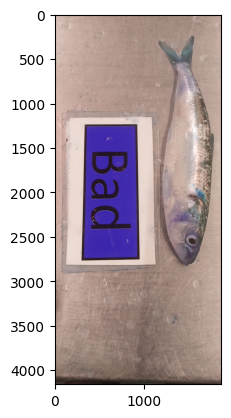

In [14]:
plt.imshow(cv2.imread(img_path))

In [12]:
len(data)

1

In [13]:
# Create a DataFrame
df = pd.DataFrame(data, columns=['Filename', 'FishHeight', 'FishWidth',
                                 'FishDiagonal', 'ScaleDiagonal', 'ScaleWidth',
                                 'OnePixelValue', 'Scale', 'Fish',
                                 'Circumference', 'Area'])

# File path
file_path = 'test_img_data.csv'

# Save DataFrame to CSV
df.to_csv(file_path, index=False)

df

,Filename,FishHeight,FishWidth,FishDiagonal,ScaleDiagonal,ScaleWidth,OnePixelValue,Scale,Fish,Circumference,Area
0,IMG20230609094603.jpg,14,3,15,11,5,0.005723,True,True,36,32


In [16]:
def create_df(train_folder):
    data = []
    Img_count = 0
    labels = {"Bad":0, "Good":1}
    for label in labels.keys():
        folder_path = os.path.join(train_folder, label)
        if not os.path.isdir(folder_path): continue
        print(f'{label} : {len(os.listdir(folder_path))}')
        Img_count += len(os.listdir(folder_path))
        for file in tqdm(os.listdir(folder_path), desc=f'Loading {label} images '):
            img_path = os.path.join(folder_path, file)
            (fish_hcm, fish_wcm, fish_dcm,
            scale_dcm, scale_wcm, fish, scale,
             fish_img_list, one_pixel_value) = fish_measures(img_path)
            if fish_img_list != None:
                for fish_img in fish_img_list:
                    circumference, area = circumference_area(fish_img)
                    if one_pixel_value != 0:
                        circumference = int(circumference * one_pixel_value)
                        area = int(area * one_pixel_value * one_pixel_value)
                    data.append((file, fish_hcm, fish_wcm, fish_dcm,
                         scale_dcm, scale_wcm, one_pixel_value,
                         scale, fish, circumference, area, labels[label]))
            else:
                circumference, area = (0, 0)
                data.append((file, fish_hcm, fish_wcm, fish_dcm,
                             scale_dcm, scale_wcm, one_pixel_value,
                            scale, fish, circumference, area, labels[label]))
    print(f'{Img_count} images loaded')
    return data

In [17]:
train_folder = r"/content/drive/MyDrive/Sowmya /models/card detection/combined_manual/sardine"
data = create_df(train_folder)

Bad : 905


Loading Bad images : 100%|██████████| 905/905 [39:53<00:00,  2.64s/it]


Good : 469


Loading Good images : 100%|██████████| 469/469 [21:30<00:00,  2.75s/it]

1374 images loaded


In [18]:
df = pd.DataFrame(data, columns=['Filename', 'FishHeight(cm)', 'FishWidth(cm)',
                                 'FishDiagonal(cm)', 'ScaleDiagonal(cm)', 'ScaleWidth(cm)',
                                 'one_pixel_value', 'Scale Detected', 'Fish Detected',
                                 'Circumference(cm)', 'Area(cm)', 'Label'])

df.to_csv(r"cards_data.csv", index=False)

In [19]:
n = pd.read_csv("cards_data.csv")

In [20]:
n.shape

(1374, 12)

In [ ]:
# duplicates = n[n.duplicated(subset=['Filename'], keep=False)]
# duplicates

In [21]:
n.drop_duplicates(subset=['Filename'], keep='first', inplace=True)

In [22]:
n.shape

(1373, 12)

In [23]:
n.loc[n['Fish Detected']==False]

,Filename,FishHeight(cm),FishWidth(cm),FishDiagonal(cm),ScaleDiagonal(cm),ScaleWidth(cm),one_pixel_value,Scale Detected,Fish Detected,Circumference(cm),Area(cm),Label
206,IMG20230519075106.jpg,0,0,0,0,0,0.0,False,False,0.0,0.0,0
274,IMG_20240227_095644467.jpg,0,0,0,0,0,0.0,False,False,0.0,0.0,0
277,IMG_20240227_100506443.jpg,0,0,0,0,0,0.0,False,False,0.0,0.0,0
885,20240222102900592_sardine_bad.jpeg,0,0,0,0,0,0.0,False,False,0.0,0.0,0
886,20240222102916293_sardine_bad.jpeg,0,0,0,0,0,0.0,False,False,0.0,0.0,0


In [ ]:
n.shape

(1595, 12)

In [24]:
n.loc[n['Scale Detected']==False]

,Filename,FishHeight(cm),FishWidth(cm),FishDiagonal(cm),ScaleDiagonal(cm),ScaleWidth(cm),one_pixel_value,Scale Detected,Fish Detected,Circumference(cm),Area(cm),Label
0,IMG20230523095949.jpg,0,0,0,0,0,0.0,False,True,6249.313216,852393.5,0
13,IMG20230523095637.jpg,0,0,0,0,0,0.0,False,True,4105.628995,486439.0,0
169,IMG20230609091738.jpg,0,0,0,0,0,0.0,False,True,3773.949499,454252.0,0
206,IMG20230519075106.jpg,0,0,0,0,0,0.0,False,False,0.000000,0.0,0
256,IMG_20240227_094647360.jpg,0,0,0,0,0,0.0,False,True,5795.891840,725836.5,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1369,20240224092149627_sardine_good.jpeg,0,0,0,0,0,0.0,False,True,6169.673584,769626.0,1
1370,20240302103232774_sardine_good.jpeg,0,0,0,0,0,0.0,False,True,5598.882605,777278.5,1
1371,20240319085734332_sardine_good.jpeg,0,0,0,0,0,0.0,False,True,5242.764856,700032.5,1
1372,20240319085742298_sardine_good.jpeg,0,0,0,0,0,0.0,False,True,5580.705984,624611.5,1


In [ ]:
k = n[((n['Scale Detected'] == True) & (n['Fish Detected'] == True))]

In [ ]:
k

,Filename,FishHeight(cm),FishWidth(cm),FishDiagonal(cm),ScaleDiagonal(cm),ScaleWidth(cm),one_pixel_value,Scale Detected,Fish Detected,Circumference(cm),Area(cm),Label
0,20240130093208534_sardine_bad.jpeg,12,3,12,16,3,0.006817,True,True,31.0,21.0,0
1,20240130093304262_sardine_bad.jpeg,14,2,14,16,2,0.007674,True,True,33.0,24.0,0
2,20240130093323026_sardine_bad.jpeg,12,2,12,16,2,0.006811,True,True,30.0,18.0,0
3,20240130093336802_sardine_bad.jpeg,13,3,13,16,3,0.007561,True,True,31.0,21.0,0
4,20240130093404006_sardine_bad.jpeg,14,4,15,16,3,0.006885,True,True,35.0,27.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1590,IMG_20240227_094359873.jpg,17,3,17,16,3,0.006544,True,True,42.0,37.0,1
1591,IMG_20240227_094404025.jpg,18,3,19,16,3,0.006377,True,True,46.0,43.0,1
1592,IMG_20240227_094408879.jpg,17,3,17,16,2,0.006267,True,True,42.0,38.0,1
1593,IMG_20240227_094412858.jpg,17,4,18,16,3,0.006026,True,True,43.0,39.0,1


In [ ]:
k['ScaleDiagonal(cm)'].value_counts()

16    1480
Name: ScaleDiagonal(cm), dtype: int64

In [ ]:
k['Label'].value_counts()

1    783
0    697
Name: Label, dtype: int64

In [ ]:
k.shape

(1480, 12)

In [ ]:
697+697

1394

# Train data

In [ ]:
# Train data
Bad_df = k[k['Label']==0]
Good_df = k[k['Label']==1].iloc[:697]

In [ ]:
def plot_hist(colname):
    # Plot histogram with black edges
    plt.figure()
    plt.hist(Bad_df[colname], edgecolor='black', color='red', alpha=0.5, label='Bad')
    plt.hist(Good_df[colname], edgecolor='black', color='blue', alpha=0.5, label='Good')
    plt.xlabel(colname)
    plt.ylabel('Count')
    plt.title(f'Histogram of {colname}')
    plt.legend()
    plt.show()

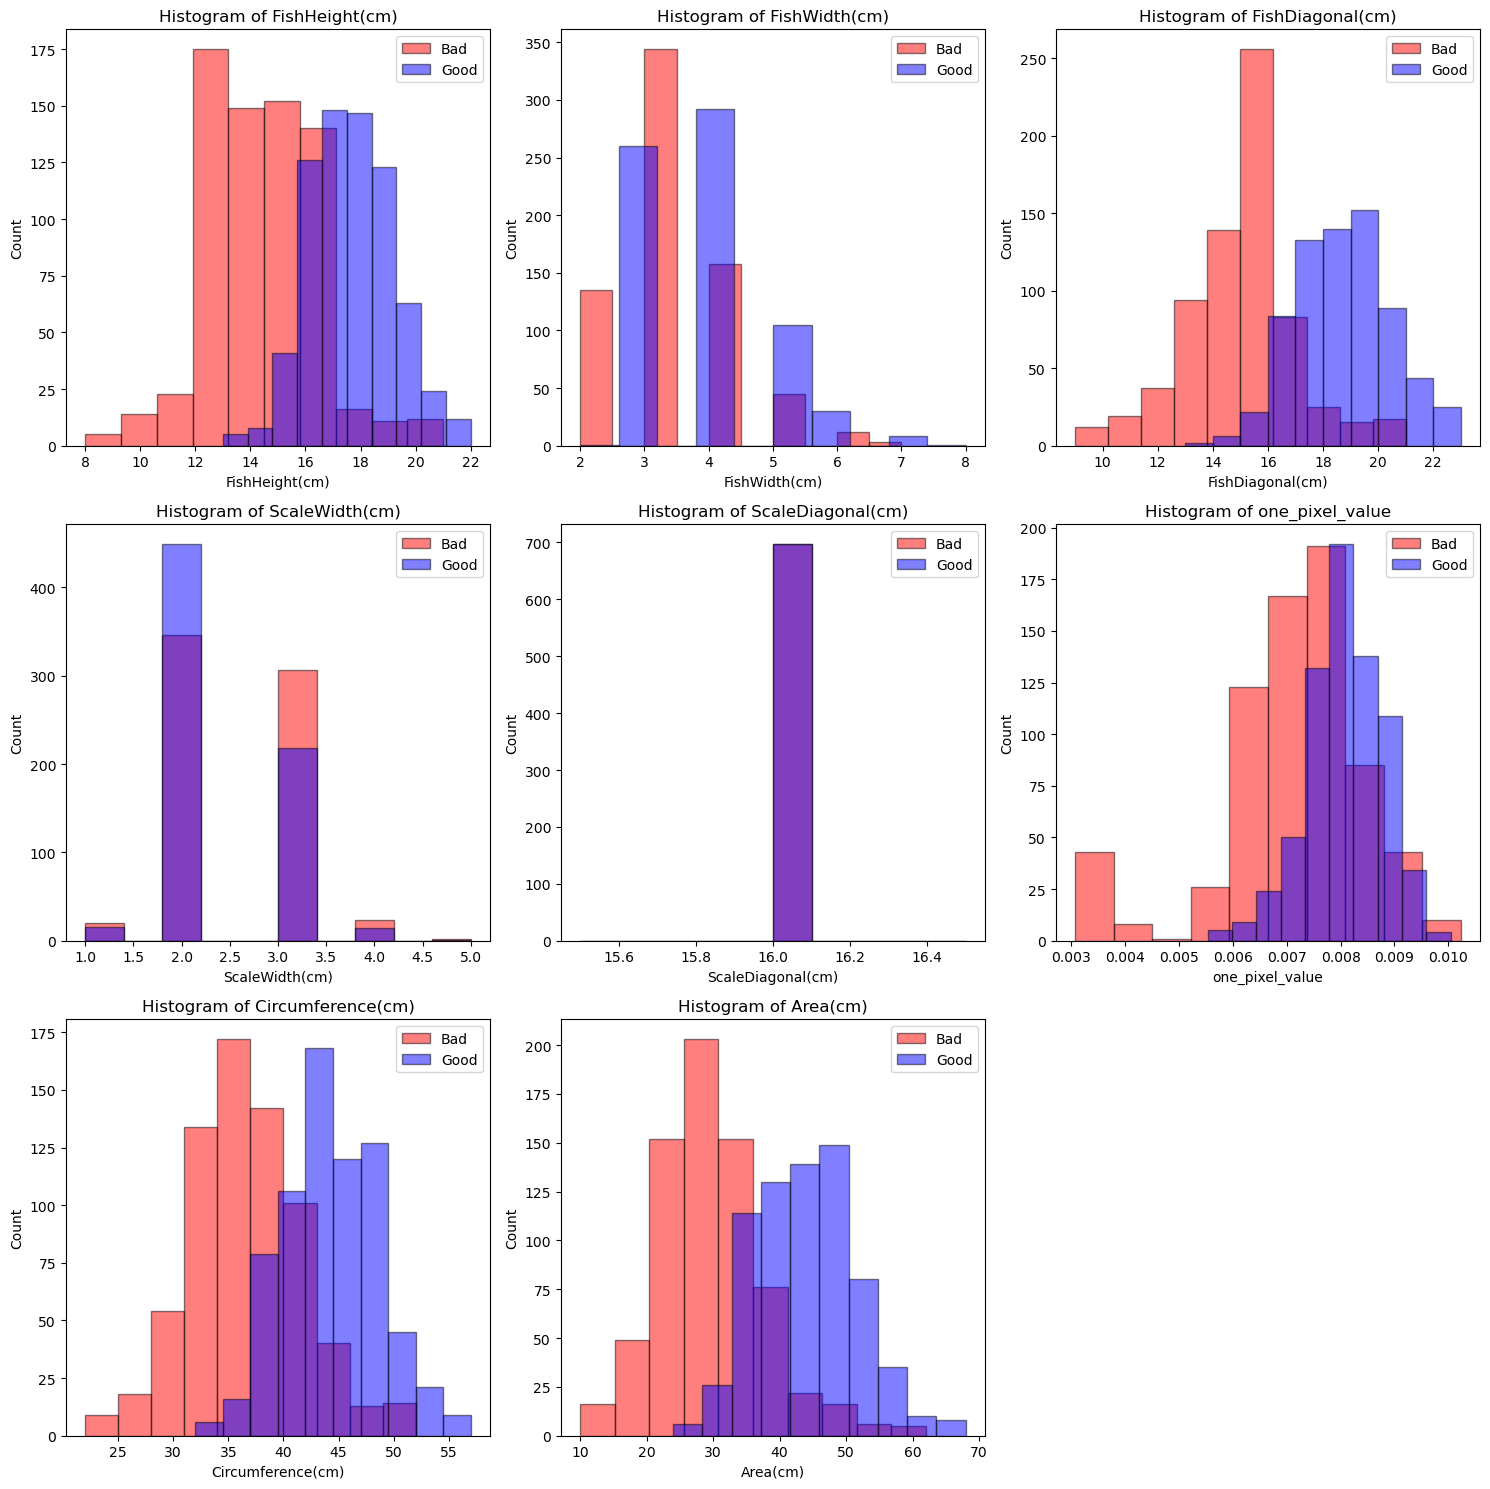

In [ ]:
import math

def plot_hist(colname_list):
    num_plots = len(colname_list)
    num_cols = min(num_plots, 3)  # Assuming a maximum of 3 columns for better visualization
    num_rows = math.ceil(num_plots / num_cols)

    fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(15, 15))

    for i, colname in enumerate(colname_list):
        row_index = i // num_cols
        col_index = i % num_cols
        ax = axes[row_index, col_index] if num_plots > 1 else axes
        ax.hist(Bad_df[colname], edgecolor='black', color='red', alpha=0.5, label='Bad')
        ax.hist(Good_df[colname], edgecolor='black', color='blue', alpha=0.5, label='Good')
        ax.set_xlabel(colname)
        ax.set_ylabel('Count')
        ax.set_title(f'Histogram of {colname}')
        ax.legend()

    if num_plots < num_rows * num_cols:
        # Hide empty subplots
        for i in range(num_plots, num_rows * num_cols):
            row_index = i // num_cols
            col_index = i % num_cols
            ax = axes[row_index, col_index] if num_plots > 1 else axes
            ax.axis('off')

    plt.tight_layout()
    plt.show()

# Example usage
plot_hist(['FishHeight(cm)', 'FishWidth(cm)', 'FishDiagonal(cm)',
           'ScaleWidth(cm)', 'ScaleDiagonal(cm)', 'one_pixel_value',
           'Circumference(cm)', 'Area(cm)'])

In [ ]:
k[k['ScaleWidth(cm)']>3.5]

,Filename,FishHeight(cm),FishWidth(cm),FishDiagonal(cm),ScaleDiagonal(cm),ScaleWidth(cm),one_pixel_value,Scale Detected,Fish Detected,Circumference(cm),Area(cm),Label
86,20240213114826464_sardine_bad.jpeg,17,4,18,16,4,0.009895,True,True,42.0,44.0,0
114,20240213115813049_sardine_bad.jpeg,17,7,19,16,5,0.008235,True,True,44.0,50.0,0
140,20240220101342051_sardine_bad.jpeg,13,4,14,16,4,0.008635,True,True,33.0,25.0,0
196,20240222101447988_sardine_bad.jpeg,17,3,17,16,4,0.007726,True,True,42.0,41.0,0
224,20240228093032129_sardine_bad.jpeg,13,2,13,16,4,0.006382,True,True,33.0,24.0,0
225,20240228093043257_sardine_bad.jpeg,14,3,14,16,4,0.005984,True,True,34.0,26.0,0
234,20240228093246595_sardine_bad.jpeg,13,3,13,16,4,0.006095,True,True,32.0,22.0,0
243,20240228093516830_sardine_bad.jpeg,13,2,14,16,4,0.006475,True,True,33.0,24.0,0
273,20240228094131503_sardine_bad.jpeg,15,3,15,16,4,0.007425,True,True,37.0,30.0,0
288,20240228094440341_sardine_bad.jpeg,13,4,13,16,4,0.008417,True,True,33.0,25.0,0


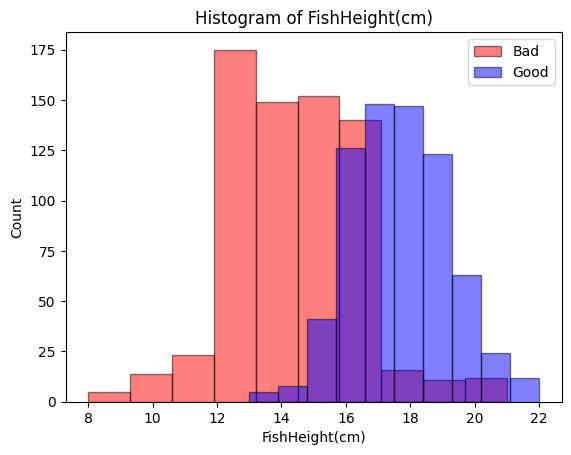

In [ ]:
plot_hist('FishHeight(cm)')

In [ ]:
Bad_df.columns

Index(['Filename', 'FishHeight(cm)', 'FishWidth(cm)', 'FishDiagonal(cm)',
       'ScaleWidth(cm)', 'ScaleDiagonal(cm)', 'one_pixel_value',
       'Scale Detected', 'Fish Detected', 'Circumference(cm)', 'Area(cm)',
       'Label'],
      dtype='object')

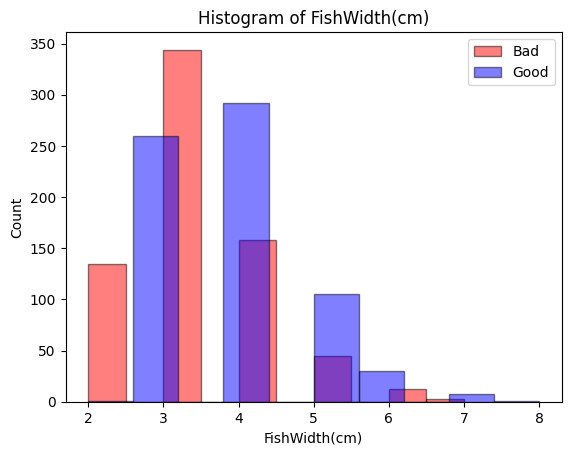

In [ ]:
plot_hist('FishWidth(cm)')

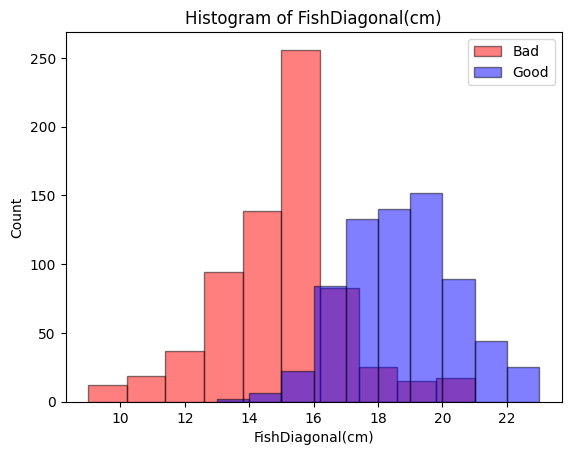

In [ ]:
plot_hist('FishDiagonal(cm)')

# Test data

In [ ]:
Bad_df = k[k['Label']==0].iloc[:22]
Good_df = k[k['Label']==1]

In [ ]:
Good_df

,Filename,FishHeight(cm),FishWidth(cm),FishDiagonal(cm),ScaleDiagonal(cm),ScaleWidth(cm),one_pixel_value,Scale Detected,Fish Detected,Circumference(cm),Area(cm),Label
60,IMG_20240227_094420718.jpg,14,5,15,16,3,0.006496,True,True,36.0,30.0,1
61,IMG_20240227_100114847.jpg,12,2,12,16,3,0.006170,True,True,30.0,21.0,1
63,IMG_20240227_101023687.jpg,14,2,14,16,3,0.006938,True,True,33.0,23.0,1
65,IMG_20240227_101030931.jpg,11,3,12,16,3,0.006478,True,True,29.0,18.0,1
66,IMG_20240227_101033727.jpg,10,2,10,16,3,0.005966,True,True,24.0,14.0,1
67,IMG_20240227_101038544.jpg,13,3,14,16,2,0.006658,True,True,33.0,25.0,1
68,IMG_20240227_101041385.jpg,15,3,15,16,2,0.007214,True,True,37.0,30.0,1
69,IMG_20240227_101046462.jpg,11,2,12,16,3,0.006390,True,True,29.0,18.0,1
70,IMG_20240227_101048996.jpg,11,2,11,16,2,0.006349,True,True,28.0,17.0,1
71,IMG_20240227_101052916.jpg,13,4,14,16,2,0.007136,True,True,33.0,25.0,1


In [ ]:
Bad_df

,Filename,FishHeight(cm),FishWidth(cm),FishDiagonal(cm),ScaleDiagonal(cm),ScaleWidth(cm),one_pixel_value,Scale Detected,Fish Detected,Circumference(cm),Area(cm),Label
0,IMG_20240227_103137093.jpg,15,3,15,16,2,0.007692,True,True,37.0,30.0,0
1,IMG_20240227_103140259.jpg,12,3,13,16,3,0.007491,True,True,31.0,21.0,0
2,IMG_20240227_103142638.jpg,14,2,14,16,2,0.007944,True,True,34.0,24.0,0
3,IMG_20240227_103149552.jpg,14,3,14,16,2,0.007972,True,True,35.0,30.0,0
4,IMG_20240227_103151989.jpg,15,3,16,16,3,0.008184,True,True,38.0,31.0,0
5,IMG_20240227_103155677.jpg,13,4,14,16,2,0.008004,True,True,33.0,27.0,0
6,IMG_20240227_103158020.jpg,14,3,14,16,2,0.007968,True,True,34.0,25.0,0
7,IMG_20240227_103201538.jpg,13,2,14,16,2,0.008338,True,True,33.0,25.0,0
8,IMG_20240227_103203915.jpg,13,3,13,16,2,0.008342,True,True,32.0,25.0,0
9,IMG_20240227_103208085.jpg,14,2,15,16,2,0.007812,True,True,36.0,29.0,0


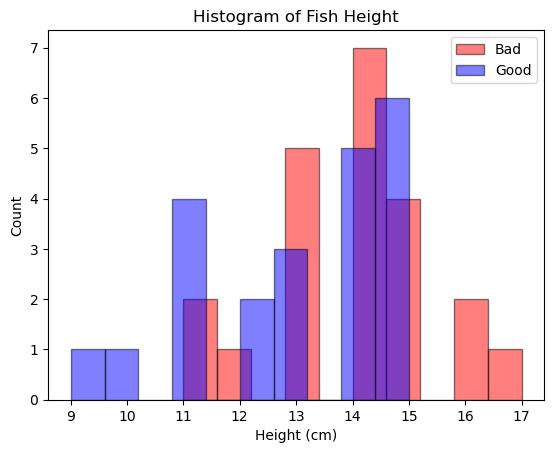

In [ ]:
# Plot histogram with black edges
plt.figure()
plt.hist(Bad_df['Height(cm)'], edgecolor='black', color='red', alpha=0.5, label='Bad')
plt.hist(Good_df['Height(cm)'], edgecolor='black', color='blue', alpha=0.5, label='Good')
plt.xlabel('Height (cm)')
plt.ylabel('Count')
plt.title('Histogram of Fish Height')
plt.legend()
plt.show()

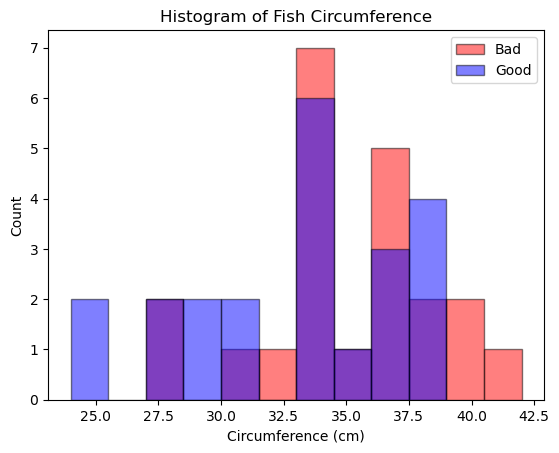

In [ ]:
# Plot histogram with black edges
plt.figure()
plt.hist(Bad_df['Circumference(cm)'], edgecolor='black', color='red', alpha=0.5, label='Bad')
plt.hist(Good_df['Circumference(cm)'], edgecolor='black', color='blue', alpha=0.5, label='Good')
plt.xlabel('Circumference (cm)')
plt.ylabel('Count')
plt.title('Histogram of Fish Circumference')
plt.legend()
plt.show()

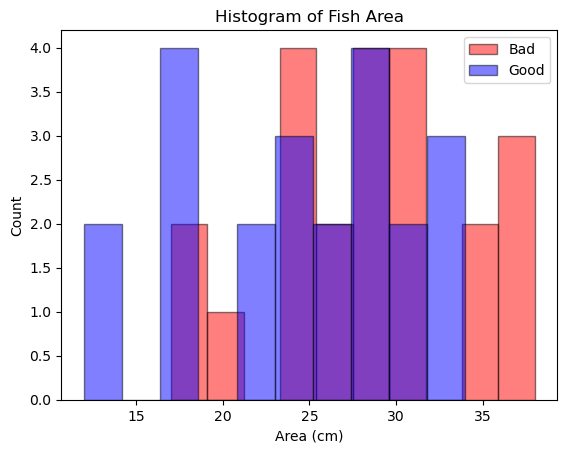

In [ ]:
# Plot histogram with black edges
plt.figure()
plt.hist(Bad_df['Area(cm)'], edgecolor='black', color='red', alpha=0.5, label='Bad')
plt.hist(Good_df['Area(cm)'], edgecolor='black', color='blue', alpha=0.5, label='Good')
plt.xlabel('Area (cm)')
plt.ylabel('Count')
plt.title('Histogram of Fish Area')
plt.legend()
plt.show()

In [ ]:
m = k.iloc[:1394] # for balanced training data

In [ ]:
m = k # for test data

In [ ]:
m.shape

(1480, 12)

In [ ]:
m

,Filename,FishHeight(cm),FishWidth(cm),FishDiagonal(cm),ScaleDiagonal(cm),ScaleWidth(cm),one_pixel_value,Scale Detected,Fish Detected,Circumference(cm),Area(cm),Label
0,20240130093208534_sardine_bad.jpeg,12,3,12,16,3,0.006817,True,True,31.0,21.0,0
1,20240130093304262_sardine_bad.jpeg,14,2,14,16,2,0.007674,True,True,33.0,24.0,0
2,20240130093323026_sardine_bad.jpeg,12,2,12,16,2,0.006811,True,True,30.0,18.0,0
3,20240130093336802_sardine_bad.jpeg,13,3,13,16,3,0.007561,True,True,31.0,21.0,0
4,20240130093404006_sardine_bad.jpeg,14,4,15,16,3,0.006885,True,True,35.0,27.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1590,IMG_20240227_094359873.jpg,17,3,17,16,3,0.006544,True,True,42.0,37.0,1
1591,IMG_20240227_094404025.jpg,18,3,19,16,3,0.006377,True,True,46.0,43.0,1
1592,IMG_20240227_094408879.jpg,17,3,17,16,2,0.006267,True,True,42.0,38.0,1
1593,IMG_20240227_094412858.jpg,17,4,18,16,3,0.006026,True,True,43.0,39.0,1


In [ ]:
m.columns

Index(['Filename', 'FishHeight(cm)', 'FishWidth(cm)', 'FishDiagonal(cm)',
       'ScaleDiagonal(cm)', 'ScaleWidth(cm)', 'one_pixel_value',
       'Scale Detected', 'Fish Detected', 'Circumference(cm)', 'Area(cm)',
       'Label'],
      dtype='object')

In [ ]:
# train_df = m[['Height(cm)', 'Circumference(cm)',
#               'Area(cm)', 'Label']]

train_df = m[['FishHeight(cm)', 'FishWidth(cm)', 'FishDiagonal(cm)',
       'ScaleDiagonal(cm)', 'ScaleWidth(cm)', 'one_pixel_value',
       'Circumference(cm)', 'Area(cm)', 'Label']]

train_df = m[['FishWidth(cm)', 'FishDiagonal(cm)',
       'ScaleDiagonal(cm)', 'ScaleWidth(cm)', 'one_pixel_value',
       'Circumference(cm)', 'Area(cm)', 'Label']]

In [ ]:
train_df

,FishWidth(cm),FishDiagonal(cm),ScaleDiagonal(cm),ScaleWidth(cm),one_pixel_value,Circumference(cm),Area(cm),Label
0,3,12,16,3,0.006817,31.0,21.0,0
1,2,14,16,2,0.007674,33.0,24.0,0
2,2,12,16,2,0.006811,30.0,18.0,0
3,3,13,16,3,0.007561,31.0,21.0,0
4,4,15,16,3,0.006885,35.0,27.0,0
...,...,...,...,...,...,...,...,...
1590,3,17,16,3,0.006544,42.0,37.0,1
1591,3,19,16,3,0.006377,46.0,43.0,1
1592,3,17,16,2,0.006267,42.0,38.0,1
1593,4,18,16,3,0.006026,43.0,39.0,1


In [ ]:
# Split the data into features (X) and target variable (y)
# X = train_df[['Height(cm)', 'Circumference(cm)', 'Area(cm)']]  # Features
# X = train_df[['Height(cm)']]  # Features

X = train_df[['FishWidth(cm)', 'FishDiagonal(cm)', 'one_pixel_value', 'ScaleWidth(cm)',
       'Circumference(cm)', 'Area(cm)']]  # Features

y = train_df['Label']  # Target variable

In [ ]:
print("Features (X):")
X.head()

Features (X):


,FishWidth(cm),FishDiagonal(cm),one_pixel_value,ScaleWidth(cm),Circumference(cm),Area(cm)
0,3,12,0.006817,3,31.0,21.0
1,2,14,0.007674,2,33.0,24.0
2,2,12,0.006811,2,30.0,18.0
3,3,13,0.007561,3,31.0,21.0
4,4,15,0.006885,3,35.0,27.0


In [ ]:
print("\nTarget variable (y):")
y.tail()


Target variable (y):


1590    1
1591    1
1592    1
1593    1
1594    1
Name: Label, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import pickle

In [ ]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=y)

# Model Training

Training Decision Tree...
Accuracy for Decision Tree: 0.8006756756756757

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.78       139
           1       0.80      0.83      0.82       157

    accuracy                           0.80       296
   macro avg       0.80      0.80      0.80       296
weighted avg       0.80      0.80      0.80       296



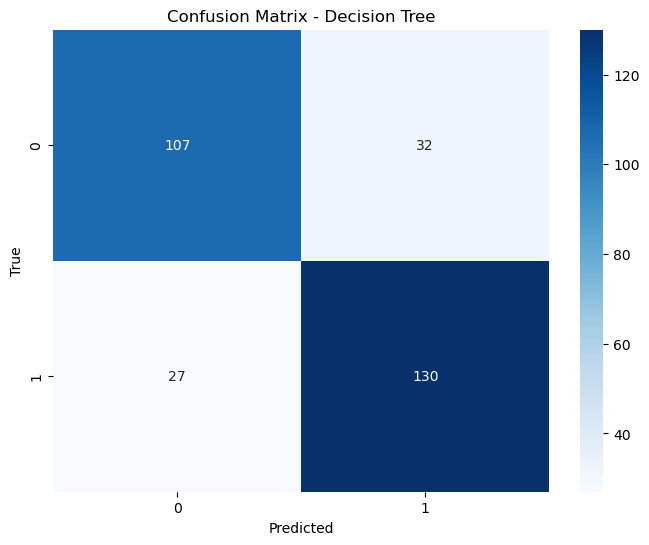

Training Random Forest...
Accuracy for Random Forest: 0.8513513513513513

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.82      0.84       139
           1       0.85      0.88      0.86       157

    accuracy                           0.85       296
   macro avg       0.85      0.85      0.85       296
weighted avg       0.85      0.85      0.85       296



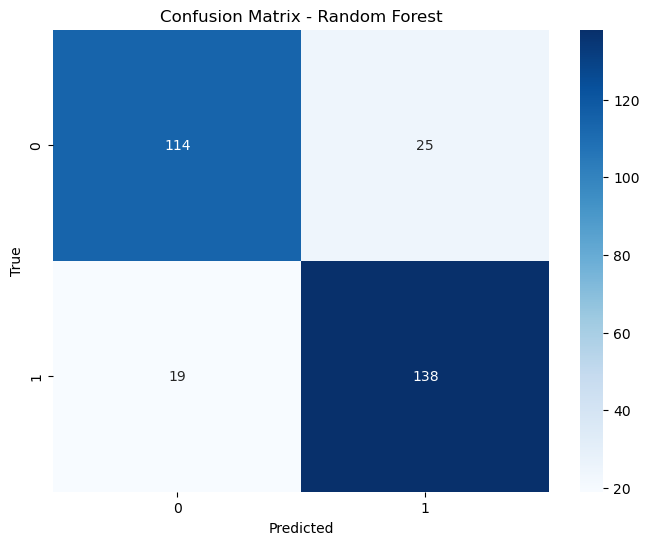

Training K-Nearest Neighbors...
Accuracy for K-Nearest Neighbors: 0.8141891891891891

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.76      0.79       139
           1       0.80      0.86      0.83       157

    accuracy                           0.81       296
   macro avg       0.82      0.81      0.81       296
weighted avg       0.82      0.81      0.81       296



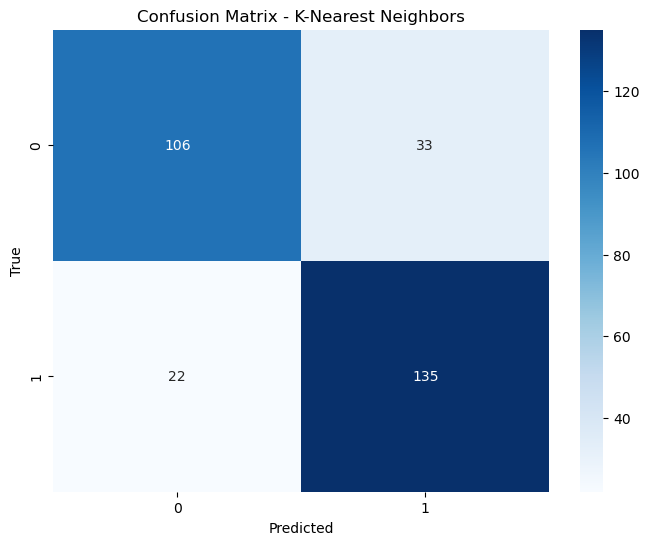

Training Naive Bayes...
Accuracy for Naive Bayes: 0.847972972972973

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.81      0.83       139
           1       0.84      0.89      0.86       157

    accuracy                           0.85       296
   macro avg       0.85      0.85      0.85       296
weighted avg       0.85      0.85      0.85       296



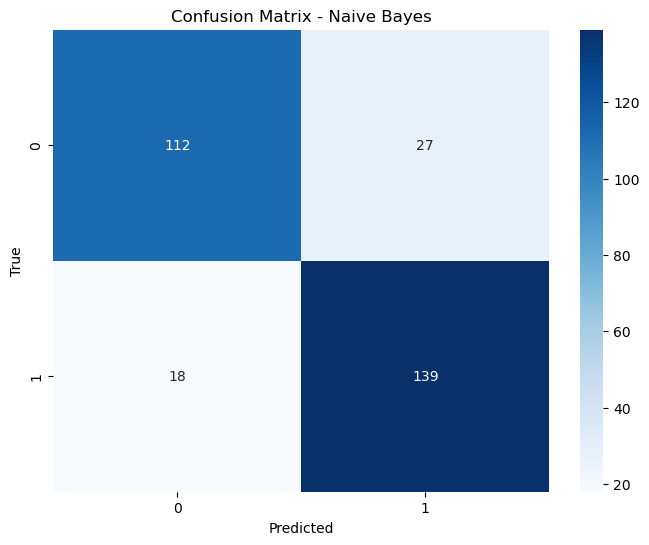

Training XGBClassifier...
Accuracy for XGBClassifier: 0.8513513513513513

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.83      0.84       139
           1       0.85      0.87      0.86       157

    accuracy                           0.85       296
   macro avg       0.85      0.85      0.85       296
weighted avg       0.85      0.85      0.85       296



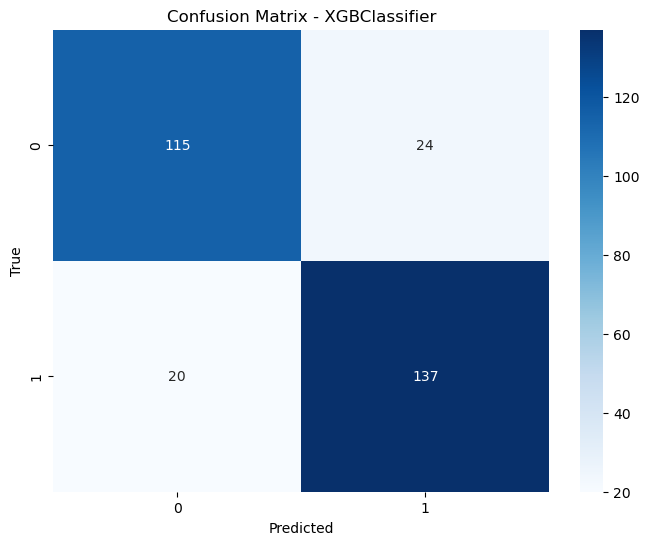

Training Logistic Regression...
Accuracy for Logistic Regression: 0.8412162162162162

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.82      0.83       139
           1       0.84      0.86      0.85       157

    accuracy                           0.84       296
   macro avg       0.84      0.84      0.84       296
weighted avg       0.84      0.84      0.84       296



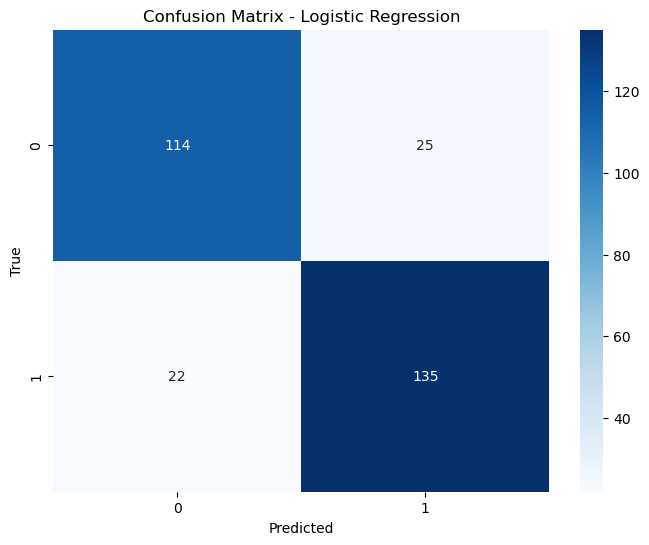

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

# Define classifiers
classifiers = {
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "XGBClassifier": XGBClassifier(),
    "Logistic Regression": LogisticRegression()
}


# Train and evaluate classifiers
for name, clf in classifiers.items():
    print(f"Training {name}...")
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy for {name}: {accuracy}\n")

    # Generate confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Generate classification report
    report = classification_report(y_test, y_pred)

    # Print the classification report
    print("Classification Report:")
    print(report)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()
    plt.close()

Best Model

In [ ]:
clf = GaussianNB()
name = "Naive Bayes"
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy for {name}: {accuracy}")

Accuracy for Naive Bayes: 0.8637992831541219


Save Best Model

In [ ]:
model_path = 'naive_bayes_model2.pkl'

In [ ]:
model = clf
with open(model_path, 'wb') as f:
    pickle.dump(model, f)

Load the ML model

In [ ]:
with open(model_path, 'rb') as f:
    model = pickle.load(f)

Test with a folder data

In [ ]:
X_test = X
y_test = y

# Evaluate the model
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy for model: {accuracy}\n")

# Generate classification report
report = classification_report(y_test, y_pred)

# Print the classification report
print("Classification Report:")
print(report)

Accuracy for model: 0.68

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.96      0.81        53
           1       0.00      0.00      0.00        22

    accuracy                           0.68        75
   macro avg       0.35      0.48      0.40        75
weighted avg       0.49      0.68      0.57        75



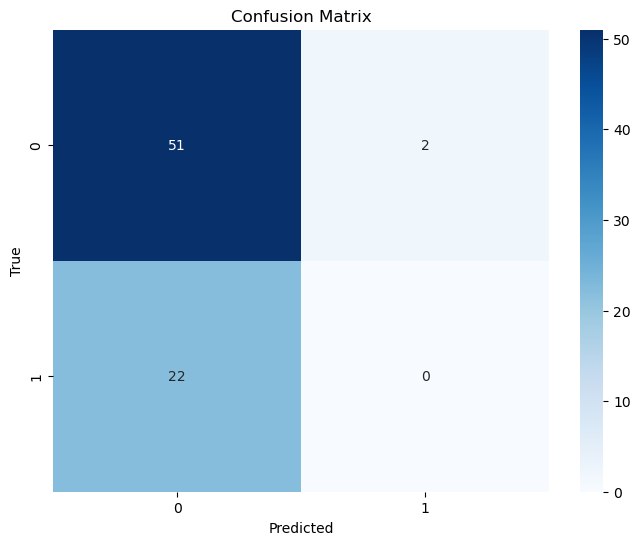

In [ ]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix')
plt.show()
plt.close()

# Test an image

In [ ]:
test = pd.read_csv(r"C:\Users\sowmy\Downloads\QzenseLabs\test_img_data.csv")
test

,Height,Width,OnePixelValue,Scale,Fish,Circumference,Area
0,17,5,0.008163,True,True,42,43


In [ ]:
def pred_single_img(test, model):
    predictions = []
    for index, row in test.iterrows():
        if row['Scale']==False:
            print(f'Scale not detected @ {index}')
            break
        if row['Fish']==False:
            print(f'Fish not detected @ {index}')
            break
        Height = row['Height']
        Circumference = row['Circumference']
        Area = row['Area']
        X_test = [[Height, Circumference, Area]]
        pred = model.predict(X_test)
        # Get probability estimates for the predicted labels
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_test)
            print(f"Probability :", y_proba)
        predictions.append(pred)
    return predictions

In [ ]:
predictions = pred_single_img(test, model)

Probability : [[0.04051524 0.95948476]]


c:\Users\sowmy\anaconda3\envs\opencv_env\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
c:\Users\sowmy\anaconda3\envs\opencv_env\lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [ ]:
for i in predictions:
    print(i[0])

1
